In [1]:
import pandas as pd
import os
import globals as gl
import matplotlib.pyplot as plt
import PcmPy as pcm
import numpy as np 

Base directory found: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/
Base directory: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/


In [2]:
snS = [102, 103, 104, 106, 107]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    print(f'loading subj{sn}')
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

loading subj102
loading subj103
loading subj104
loading subj106
loading subj107


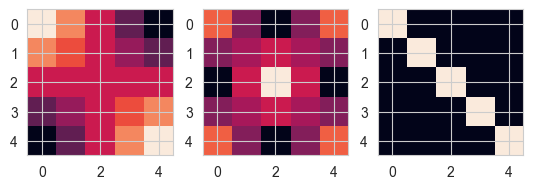

In [4]:
C = pcm.centering(5)

v_cue =  C @ np.array([-2, -1, 0, 1, 2]) 
v_cert = C @ np.array([0, 1, 2, 1, 0])

G_cue = np.outer(v_cue, v_cue)

G_cert = np.outer(v_cert, v_cert)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(G_cue)
axs[1].imshow(G_cert)
axs[2].imshow(np.eye(5))